In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bostonhoustingmlnd/housing.csv


In [40]:
import pandas as pd 
import xgboost as xgb
import sklearn
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


In [41]:
# On importe la dataset

df = pd.read_csv("/kaggle/input/bostonhoustingmlnd/housing.csv")

In [42]:
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [44]:
y = df['MEDV'] # On mets la cible dans une colonne à part
X = df.drop (columns = 'MEDV') # On enlève la cible des données d'entrainement

In [45]:
# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Séparer encore le train en train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

In [46]:
model = xgb.XGBRegressor(
    n_estimators=1000,       # on met grand, l’early stopping arrêtera avant
    learning_rate=0.05,      # plus petit = plus précis, mais besoin de plus d’arbres
    max_depth=4,             # arbres pas trop profonds (évite l’overfitting)
    random_state=42
)


In [47]:
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",        # métrique de régression
    early_stopping_rounds=20,  # stop si pas d’amélioration 20 tours
    verbose=True
)

[0]	validation_0-rmse:167719.66965
[1]	validation_0-rmse:161126.55621
[2]	validation_0-rmse:154703.84361
[3]	validation_0-rmse:148854.27943
[4]	validation_0-rmse:143526.16019
[5]	validation_0-rmse:138171.45281
[6]	validation_0-rmse:133693.74000
[7]	validation_0-rmse:129651.12437
[8]	validation_0-rmse:125327.47838
[9]	validation_0-rmse:121672.22767
[10]	validation_0-rmse:118156.54969
[11]	validation_0-rmse:114674.67840
[12]	validation_0-rmse:111640.46026
[13]	validation_0-rmse:108604.39925
[14]	validation_0-rmse:105586.00740
[15]	validation_0-rmse:103278.05377
[16]	validation_0-rmse:101049.08020
[17]	validation_0-rmse:98777.70887
[18]	validation_0-rmse:96654.31777
[19]	validation_0-rmse:94615.35732
[20]	validation_0-rmse:93075.47914
[21]	validation_0-rmse:91629.10840
[22]	validation_0-rmse:90361.75304
[23]	validation_0-rmse:89140.73157
[24]	validation_0-rmse:87691.13379
[25]	validation_0-rmse:86601.80198
[26]	validation_0-rmse:85479.16621
[27]	validation_0-rmse:84437.48788
[28]	validati

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[49]	validation_0-rmse:76368.14174
[50]	validation_0-rmse:76214.30349
[51]	validation_0-rmse:76149.98924
[52]	validation_0-rmse:76124.86867
[53]	validation_0-rmse:76115.80009
[54]	validation_0-rmse:75981.21230
[55]	validation_0-rmse:75962.24588
[56]	validation_0-rmse:75846.71797
[57]	validation_0-rmse:75976.56295
[58]	validation_0-rmse:75890.33536
[59]	validation_0-rmse:76036.70805
[60]	validation_0-rmse:76037.30304
[61]	validation_0-rmse:76002.06217
[62]	validation_0-rmse:76036.68135
[63]	validation_0-rmse:76022.15385
[64]	validation_0-rmse:76060.53172
[65]	validation_0-rmse:76070.24991
[66]	validation_0-rmse:75992.06872
[67]	validation_0-rmse:76029.60939
[68]	validation_0-rmse:76069.89100
[69]	validation_0-rmse:76070.81080
[70]	validation_0-rmse:76091.70824
[71]	validation_0-rmse:76107.30056
[72]	validation_0-rmse:76153.68067
[73]	validation_0-rmse:76180.16174
[74]	validation_0-rmse:76146.46870
[75]	validation_0-rmse:76119.56928
[76]	validation_0-rmse:76093.60686


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [48]:
model.predict(X_train) # On calcul les valeurs les plus probables de MEDV selon les autres colonnes 

array([425791.28, 494743.34, 425791.28, 482886.34, 443421.28, 445685.1 ,
       443421.28, 422665.47, 567849.4 , 374243.75, 423113.66, 443421.28,
       352576.22, 433901.28, 318873.94, 467593.62, 450158.22, 373107.03,
       255034.1 , 480873.12, 634366.8 , 422665.47, 486740.84, 446423.06,
       418422.2 , 439489.25, 452171.44, 561641.7 , 692341.7 , 503858.62,
       425892.22, 488131.06, 448436.28, 415588.47, 321816.53, 814260.3 ,
       388651.47, 725789.75, 258856.56, 255170.12, 428310.03, 434184.28,
       725587.5 , 467148.16, 322529.4 , 414766.72, 710859.9 , 421273.34,
       423113.66, 245166.72, 338520.12, 212389.45, 345784.62, 397484.1 ,
       635946.94, 470498.84, 410843.03, 326498.1 , 440560.44, 637447.75,
       423406.84, 443421.28, 429547.7 , 328273.  , 522050.47, 318873.94,
       504346.94, 374243.75, 485769.5 , 277847.97, 258711.94, 577005.1 ,
       458421.53, 611263.2 , 449603.56, 464097.4 , 329499.9 , 916673.  ,
       253580.72, 357701.16, 688575.8 , 422735.66, 

In [49]:
y_pred = model.predict(X_test)

In [50]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

61666.734818670695


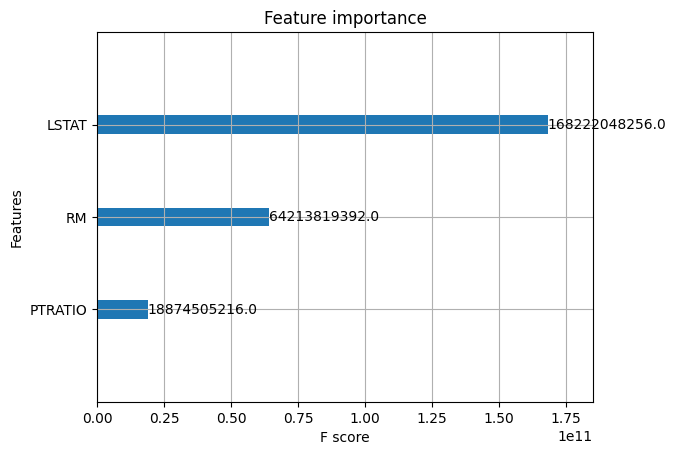

In [51]:
booster = model.get_booster()
booster.feature_names = list(X.columns)

ax = xgb.plot_importance(booster, importance_type="gain", max_num_features=20, show_values=True)
plt.show()